<a href="https://colab.research.google.com/github/chutimabo-ctrl/Pandas-review/blob/main/Homework_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#นางสาวชุติมา บุตรตะนัย 673020248-5

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

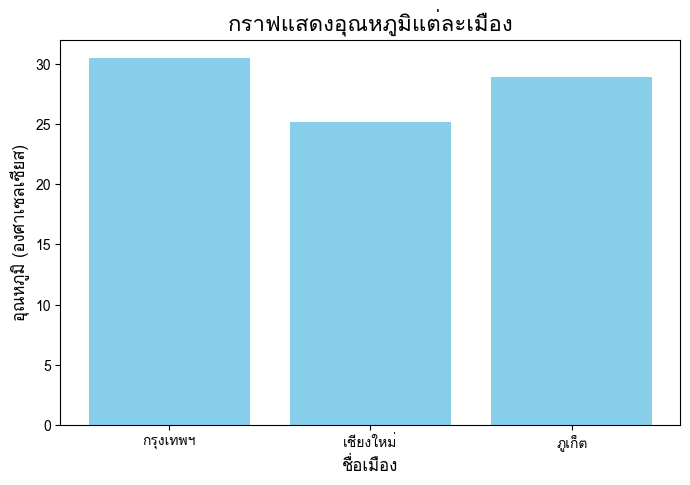

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
# สร้าง Series ชื่อ rain_by_city โดยใช้ groupby คำนวณผลรวมปริมาณฝนแยกตามเมือง
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain = rain_by_city.nlargest(3)
print("--- 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ---")
print(top3_rain)

# 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด (ร้อยละ 2 ตำแหน่ง)
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n--- 2. สัดส่วนปริมาณฝนเทียบกับรวมทั้งหมด (%) ---")
print(rain_pct)

# 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
mean_rain = rain_by_city.mean()
n_above_avg = (rain_by_city > mean_rain).sum()
print(f"\n--- 3. จำนวนเมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย ({mean_rain:.2f}): {n_above_avg} เมือง ---")

--- 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ---
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

--- 2. สัดส่วนปริมาณฝนเทียบกับรวมทั้งหมด (%) ---
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64

--- 3. จำนวนเมืองที่มีฝนรวมสูงกว่าค่าเฉลี่ย (362.97): 8 เมือง ---


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
# สร้าง DataFrame ชื่อ city_profile โดยใช้ groupby ตามโจทย์
city_profile = df.groupby(["city", "country", "region"]).agg(
    n_records=("temperature_c", "count"),
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
).reset_index()

print(city_profile.head())

       city      country   region  n_records   avg_temp  total_rain
0  Auckland  NEW ZEALAND  Oceania          1  19.800000         3.5
1  Auckland  New Zealand  Oceania         89  17.782022       348.4
2   Bangkok     Thailand     Asia         91  32.453846       685.6
3   Beijing        China     Asia         89  15.598876       250.1
4    Berlin      GERMANY   Europe          1  14.700000         0.0


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
# อ่านไฟล์ CSV พร้อมกำหนดเงื่อนไขครบถ้วนในคำสั่งเดียว
df_custom = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=["999", "-999"],
    dtype={"city": "category", "region": "category"}
).set_index("city")

# ตรวจสอบผลลัพธ์ด้วย .dtypes และ .info()
print("--- dtypes ---")
print(df_custom.dtypes)
print("\n--- info ---")
df_custom.info()

--- dtypes ---
date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

--- info ---
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
# เปรียบเทียบหน่วยความจำระหว่าง df เดิมกับ df_custom
mem_original = df[["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"]].memory_usage(deep=True).sum()
mem_custom = df_custom.memory_usage(deep=True).sum()

pct_reduction = ((mem_original - mem_custom) / mem_original) * 100
print(f"หน่วยความจำเดิม: {mem_original:,}ไบต์")
print(f"หน่วยความจำหลังปรับปรุง: {mem_custom:,}ไบต์")
print(f"หน่วยความจำลดลง: {pct_reduction:.2f}%")

หน่วยความจำเดิม: 406,908ไบต์
หน่วยความจำหลังปรับปรุง: 72,917ไบต์
หน่วยความจำลดลง: 82.08%


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
# ใช้ chunksize คำนวณอุณหภูมิสูงสุด ต่ำสุด และสะสมข้อมูลหาค่าเฉลี่ยรายเมือง
max_temp = -float('inf')
min_temp = float('inf')

city_temp_sum = {}
city_temp_count = {}

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    # อัปเดตค่าสูงสุดและต่ำสุดของทั้งไฟล์
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()
    if chunk_max > max_temp: max_temp = chunk_max
    if chunk_min < min_temp: min_temp = chunk_min

    # สะสมผลรวมและจำนวนนับเพื่อหาค่าเฉลี่ยรายเมือง
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    for city, row in grouped.iterrows():
        city_temp_sum[city] = city_temp_sum.get(city, 0) + row["sum"]
        city_temp_count[city] = city_temp_count.get(city, 0) + row["count"]

print(f"อุณหภูมิสูงสุดของทั้งไฟล์: {max_temp}")
print(f"อุณหภูมิที่ต่ำสุดของทั้งไฟล์: {min_temp}")

print("\nอุณหภูมิเฉลี่ยรายเมือง:")
for city in city_temp_sum:
    avg = city_temp_sum[city] / city_temp_count[city]
    print(f"- {city}: {avg:.2f}")

อุณหภูมิสูงสุดของทั้งไฟล์: 999.0
อุณหภูมิที่ต่ำสุดของทั้งไฟล์: -88.0

อุณหภูมิเฉลี่ยรายเมือง:
- Auckland: 17.80
- Bangkok: 32.45
- Beijing: 15.60
- Berlin: 12.38
- Buenos Aires: 19.17
- Cairo: 26.09
- Cape Town: 30.16
- Chiang Mai: 29.68
- Lagos: 29.49
- Lima: 21.49
- London: 13.49
- Los Angeles: 20.66
- Mexico City: 19.19
- Moscow: 7.23
- Mumbai: 30.87
- Nairobi: 21.44
- New York: 15.48
- Paris: 25.81
- Sao Paulo: 22.84
- Singapore: 40.08
- Sydney: 20.35
- Tokyo: 18.41
- Toronto: 11.61


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
# สร้าง DataFrame สรุปข้อมูลเชิงคุณภาพของทุกคอลัมน์โดยไม่ใช้การวนซ้ำทีละคอลัมน์
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.iloc[0]
}).sort_values(by="n_missing", ascending=False)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
# ตรวจสอบความผิดปกติทางกายภาพของข้อมูล
invalid_temp = ((df["temperature_c"] < -60) | (df["temperature_c"] > 60)).sum()
invalid_humidity = ((df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)).sum()

# จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ (ระวังการนับซ้ำโดยใช้เงื่อนไขรวม)
invalid_any = (
    (df["temperature_c"] < -60) | (df["temperature_c"] > 60) |
    (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)
).sum()

print(f"1. อุณหภูมิผิดภูมินอกช่วง -60 ถึง 60: {invalid_temp} แถว")
print(f"2. ความชื้นผิดปกตินอกช่วง 0 ถึง 100: {invalid_humidity} แถว")
print(f"3. แถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: {invalid_any} แถว")

1. อุณหภูมิผิดภูมินอกช่วง -60 ถึง 60: 5 แถว
2. ความชื้นผิดปกตินอกช่วง 0 ถึง 100: 3 แถว
3. แถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
# 1. แสดงค่าประเทศที่ไม่สม่ำเสมอ
print("ค่าไม่ซ้ำของคอลัมน์ country:", df["country"].unique())

# 2. ทดลองใช้ .str.title() และอธิบายผลกระทบ
# อธิบาย: การใช้ .title() จะเปลี่ยนตัวอักษรตัวแรกของทุกคำเป็นพิมพ์ใหญ่ ซึ่งจะทำให้ชื่อประเทศที่มีคำเชื่อมหรือคำเฉพาะเสียหาย เช่น "United States" อาจกลายเป็นคำอื่น หรือประเทศที่มีคำว่า "of" กลายเป็น "Of" ทำให้จัดกลุ่มผิดเพี้ยน

# 3. วิธี Normalize ที่ถูกต้อง (ลบช่องว่างหัวท้าย และแปลงเป็นตัวพิมพ์เล็กหรือมาตรฐานที่ถูกต้อง)
country_normalized = df["country"].str.strip().str.title()
print("จำนวนประเทศที่ไม่ซ้ำหลัง Normalize:", country_normalized.nunique())

ค่าไม่ซ้ำของคอลัมน์ country: ['USA' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'UK' 'Thailand' 'Germany' 'Brazil' 'Canada' 'GERMANY'
 'CANADA' 'SINGAPORE' 'NEW ZEALAND' 'ARGENTINA' 'JAPAN' 'KENYA']
จำนวนประเทศที่ไม่ซ้ำหลัง Normalize: 21


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก (index 0, 2, 4, ... 18) เฉพาะ 3 คอลัมน์สุดท้าย
print("--- 1.แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย ---")
print(df.iloc[0:20:2, -3:])

# 2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน
print("\n--- 2.ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป ---")
print(df.iloc[::-1].head(5))

# 3. ค่าเดี่ยวแถวกึ่งกลางตารางและคอลัมน์สุดท้าย
mid_row = len(df) // 2
val_mid = df.iloc[mid_row, -1]
print(f"\n--- 3. ค่าที่ตำแหน่งแถว {mid_row} คอลัมน์สุดท้าย: {val_mid} ---")

--- 1.แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย ---
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6

--- 2.ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป ---
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mex

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2
# เตรียม MultiIndex DataFrame
multi_df = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
print("--- 1.ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date temperature_c ---")
print(multi_df.loc["Asia", ["date", "temperature_c"]].head(3))

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกัน
print("\n--- 2.ข้อมูลของเมือง Tokyo & Bangkok ---")
print(multi_df.loc[(slice(None), ["Tokyo", "Bangkok"]), ["date", "temperature_c"]].head(3))

# 3. ทุกภูมิภาค เฉพาะเมืองที่ขึ้นต้นด้วยตัวอักษร B
print("\n--- 3. เมืองขึ้นต้นด้วย B ---")
print(multi_df.loc[multi_df.index.get_level_values('city').str.startswith('B'), ["date", "temperature_c"]].head(3))

--- 1.ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date temperature_c ---
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9

--- 2.ข้อมูลของเมือง Tokyo & Bangkok ---
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7

--- 3. เมืองขึ้นต้นด้วย B ---
                      date  temperature_c
region city                              
Asia   Bangkok  2025-02-22           30.8
       Bangkok  2025-01-10           28.9
       Bangkok  2025-01-27           27.9


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
# รูปแบบที่ถูกต้องในการทำงานกับ DataFrame จริง (ใช้ loc กำหนดค่าโดยตรง)
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

# รูปแบบที่ถูกต้องเมื่อต้องการทำงานกับสำเนาแยกต่างหากเพื่อหลีกเลี่ยง SettingWithCopyWarning
subset_copy = df[df["city"] == "Bangkok"].copy()
subset_copy["temperature_c"] = 0

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1
# 1. ภูมิภาคเอเชีย ฝน > 5 และลม > 20
cond1 = df.query("region == 'Asia' and rainfall_mm > 5 and wind_speed_kmh > 20")

# 2. ไม่ใช่ Bangkok, Tokyo, London และความชื้นระหว่าง 40 ถึง 60
cond2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df[df.isna().sum(axis=1) >= 2]

# 4. ชื่อเมืองมีคำว่า New หรือ San
cond4 = df[df["city"].str.contains("New|San", regex=True)]

print(f"เงื่อนไข 1: {len(cond1)} แถว | เงื่อนไข 2: {len(cond2)} แถว | เงื่อนไข 3: {len(cond3)} แถว | เงื่อนไข 4: {len(cond4)} แถว")

เงื่อนไข 1: 54 แถว | เงื่อนไข 2: 470 แถว | เงื่อนไข 3: 8 แถว | เงื่อนไข 4: 90 แถว


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
# สร้างคอลัมน์ใหม่ตามโจทย์
df["temp_cleaned"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
p99_rain = df["rainfall_mm"].quantile(0.99)
df["rain_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99_rain, p99_rain)

print(df[["temperature_c", "temp_cleaned", "rainfall_mm", "rain_capped"]].tail())

      temperature_c  temp_cleaned  rainfall_mm  rain_capped
2070           17.8          17.8          7.4          7.4
2071           20.6          20.6          3.7          3.7
2072           21.7          21.7          9.5          9.5
2073            NaN           NaN          9.1          9.1
2074           11.1          11.1          6.3          6.3


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
# หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยเมืองตนเองมากที่สุด
df["city_mean_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["deviation"] = (df["temperature_c"] - df["city_mean_temp"]).abs()

idx_max_dev = df.groupby("city")["deviation"].idxmax()
result_6_3 = df.loc[idx_max_dev, ["city", "date", "temperature_c", "deviation"]]
print(result_6_3.head())

              city        date  temperature_c   deviation
1036      Auckland  2025-02-27           25.6    7.795556
67         Bangkok  2025-02-22            0.0    0.000000
1778       Beijing  2025-03-06           22.6    7.001124
1224        Berlin  2025-03-26           19.4    7.016854
1280  Buenos Aires  2025-01-19          -88.0  107.171910


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
# สร้างคอลัมน์ใหม่ด้วย .assign() เพียงคำสั่งเดียว
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week.astype(int),
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)
print(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head(3))

        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2
# 1. ตรวจสอบช่วงวันและวันที่มีข้อมูลขาดหาย
all_dates = pd.date_range(df["date"].min(), df["date"].max())
missing_dates = all_dates.difference(df["date"].unique())
print(f"ช่วงข้อมูลครอบคลุม: {df['date'].min().date()} ถึง {df['date'].max().date()} (รวม {len(all_dates)} วัน)")
print(f"วันที่มีข้อมูลขาดหายไปหรือไม่: {'มี' if len(missing_dates) > 0 else 'ไม่มี'}")

# 2. อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
df["is_weekend"] = df["date"].dt.dayofweek >= 5
print("\n--- 2. อุณหภูมิเฉลี่ย Weekend vs Weekday ---")
print(df.groupby(["region", "is_weekend"])["temperature_c"].mean().unstack())

# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง (ใช้ df["date"].dt.month แทน 'month')
city_month_rain = df.groupby(["city", df["date"].dt.month.rename("month")])["rainfall_mm"].sum().reset_index()
idx_max_rain = city_month_rain.groupby("city")["rainfall_mm"].idxmax()
print("\n--- 3. เดือนที่ฝนรวมสูงสุดของแต่ละเมือง ---")
print(city_month_rain.loc[idx_max_rain])

ช่วงข้อมูลครอบคลุม: 2025-01-01 ถึง 2025-03-31 (รวม 90 วัน)
วันที่มีข้อมูลขาดหายไปหรือไม่: ไม่มี

--- 2. อุณหภูมิเฉลี่ย Weekend vs Weekday ---
is_weekend         False      True 
region                             
Africa         27.944444  23.884466
Asia           22.978851  21.120513
Europe         15.820472  11.951961
North America  16.715686  16.841176
Oceania        18.943750  19.401923
South America  21.703141  19.844156

--- 3. เดือนที่ฝนรวมสูงสุดของแต่ละเมือง ---
            city  month  rainfall_mm
2       Auckland      3        150.0
4        Bangkok      2        243.9
7        Beijing      2         87.4
11        Berlin      3        100.1
13  Buenos Aires      2        121.2
16         Cairo      2         48.0
18     Cape Town      1         98.3
23    Chiang Mai      3        188.0
26         Lagos      3        233.0
27          Lima      1         88.0
30        London      1        117.2
33   Los Angeles      1         78.6
36   Mexico City      1        124.2
40     

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3
# สรุปข้อมูล Bangkok ราย 7 วัน
bkk_resample = (df[df["city"] == "Bangkok"]
                .set_index("date")
                .resample("7D")
                .agg({"temperature_c": "mean", "rainfall_mm": "sum"}))
print(bkk_resample.head())

            temperature_c  rainfall_mm
date                                  
2025-01-01            0.0         65.7
2025-01-08            0.0         47.6
2025-01-15            0.0         58.7
2025-01-22            0.0         50.0
2025-01-29            0.0         55.4


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1
# 1. คอลัมน์ที่มีค่าว่างมากที่สุดและร้อยละ
max_miss_col = df.isna().sum().idxmax()
max_miss_pct = df.isna().mean().max() * 100
print(f"คอลัมน์ที่มีค่าว่างมากที่สุดคือ '{max_miss_col}' คิดเป็น {max_miss_pct:.2f}%")

# 2. ตารางแสดงสัดส่วนค่าว่างอุณหภูมิแยกตามเมือง
missing_temp_city = df.groupby("city")["temperature_c"].apply(lambda s: s.isna().mean() * 100)
print("\n--- สัดส่วนค่าว่างอุณหภูมิรายเมือง (%) ---")
print(missing_temp_city.head())

# 3. หากลบแถวค่าว่างทั้งหมดด้วย dropna() จะเหลือข้อมูลคิดเป็นร้อยละเท่าใด
remaining_pct = (len(df.dropna()) / len(df)) * 100
print(f"\nข้อมูลที่เหลือหลัง dropna(): {remaining_pct:.2f}%")

คอลัมน์ที่มีค่าว่างมากที่สุดคือ 'humidity_pct' คิดเป็น 3.95%

--- สัดส่วนค่าว่างอุณหภูมิรายเมือง (%) ---
city
Auckland        0.000000
Bangkok         0.000000
Beijing         1.111111
Berlin          1.111111
Buenos Aires    1.111111
Name: temperature_c, dtype: float64

ข้อมูลที่เหลือหลัง dropna(): 88.72%


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
# เติมค่าว่าง 3 วิธี
df["temp_global_mean"] = df["temperature_c"].fillna(df["temperature_c"].mean())
df["temp_city_mean"] = df["temperature_c"].fillna(df.groupby("city")["temperature_c"].transform("mean"))
df["temp_ffill"] = df.sort_values(["city", "date"]).groupby("city")["temperature_c"].ffill()

# เปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน
comparison = df.groupby("city").agg(
    orig_std=("temperature_c", "std"),
    city_mean_std=("temp_city_mean", "std"),
    ffill_std=("temp_ffill", "std")
).round(2)
print(comparison.head())

              orig_std  city_mean_std  ffill_std
city                                            
Auckland          2.80           2.80       2.80
Bangkok           0.00           0.00       0.00
Beijing           2.87           2.86       2.87
Berlin            2.60           2.58       2.61
Buenos Aires     11.82          11.75      11.76


### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
# 1. ตรวจสอบคู่ (city, date) ที่ซ้ำกัน
dup_pairs = df.duplicated(subset=["city", "date"]).sum()
print(f"จำนวนคู่ (city, date) ที่ซ้ำกัน: {dup_pairs}")

# 2. ขจัดข้อมูลซ้ำและตรวจสอบขนาดแถว
df_clean = df.drop_duplicates(subset=["city", "date"]).copy()
print(f"จำนวนแถวหลังขจัดข้อมูลซ้ำ: {len(df_clean)} (เป้าหมาย: 2070 แถว)")

จำนวนคู่ (city, date) ที่ซ้ำกัน: 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070 (เป้าหมาย: 2070 แถว)


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 22)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
# สร้างตารางสรุปรายเมืองด้วย agg() เดียว
summary_91 = df_clean.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100)
).round(2)

print(summary_91.head())

              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok           0.00         0.00      0.00       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   

              pct_missing_temp  
city                            
Auckland                  0.00  
Bangkok                   0.00  
Beijing                   1.11  
Berlin                    1.11  
Buenos Aires              1.11  


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
df_clean["month"] = df_clean["date"].dt.month

summary_92 = df_clean.groupby(["region", "month"])["temperature_c"].mean().reset_index()

max_row = summary_92.loc[summary_92["temperature_c"].idxmax()]
min_row = summary_92.loc[summary_92["temperature_c"].idxmin()]

print("--- ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตามภูมิภาคและเดือน ---")
print(summary_92.head())

print(f"\nภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค '{max_row['region']}' เดือนที่ {max_row['month']} ({max_row['temperature_c']:.2f}°C)")
print(f"ภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค '{min_row['region']}' เดือนที่ {min_row['month']} ({min_row['temperature_c']:.2f}°C)")

--- ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตามภูมิภาคและเดือน ---
   region  month  temperature_c
0  Africa      1      22.641667
1  Africa      2      32.741441
2  Africa      3      25.414754
3    Asia      1      18.993011
4    Asia      2      21.283234

ภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค 'Africa' เดือนที่ 2 (32.74°C)
ภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค 'Europe' เดือนที่ 1 (10.40°C)


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3
# โค้ดตรวจสอบความแตกต่างระหว่าง count() และ size() รายเมือง
check_93 = df_clean.groupby("city").agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size")
)
check_93["diff"] = check_93["n_days_size"] - check_93["n_days_count"]
print(check_93[check_93["diff"] > 0].head())

              n_days_count  n_days_size  diff
city                                         
Beijing                 89           90     1
Berlin                  89           90     1
Buenos Aires            89           90     1
Cairo                   88           90     2
Cape Town               89           90     1


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1
# สร้างคอลัมน์ใหม่ด้วย transform
df_clean["rain_share"] = df_clean["rainfall_mm"] / df_clean.groupby("city")["rainfall_mm"].transform("sum")
df_clean["temp_z"] = df_clean.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
df_clean["city_rank_month"] = df_clean.groupby("city")["temperature_c"].transform(lambda s: s.rank(ascending=False))

# ตรวจสอบผลรวม rain_share เท่ากับ 1 ทุกเมือง
check_share = df_clean.groupby("city")["rain_share"].sum().round(5)
print("ตรวจสอบผลรวม rain_share ทุกเมืองเท่ากับ 1 หรือไม่:", (check_share == 1.0).all())

ตรวจสอบผลรวม rain_share ทุกเมืองเท่ากับ 1 หรือไม่: True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2
# ใช้ filter คัดเลือกเมืองที่มีข้อมูล temperature_c ไม่ว่างอย่างน้อย 88 วัน
valid_counts = df_clean.groupby("city")["temperature_c"].apply(lambda s: s.notna().sum())
filtered_cities_filter = df_clean.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)

# วิธีเทียบเท่าโดยไม่ใช้ filter (ใช้ boolean indexing จากการคำนวณ Series)
valid_city_names = valid_counts[valid_counts >= 88].index
filtered_cities_bool = df_clean[df_clean["city"].isin(valid_city_names)]

print("เมืองที่ถูกคัดออก:", set(df_clean["city"].unique()) - set(valid_city_names))

เมืองที่ถูกคัดออก: {'Lagos'}


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3
# หา 5 วันที่มีค่ามาตรฐานอุณหภูมิสูงสุดของทั้งตารางเทียบกับเมืองตนเอง
top5_z = df_clean.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
print(top5_z)

           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
# วิธีที่ 1: เรียงลำดับแล้วใช้ groupby().head(3)
t1_start = pd.Timestamp.now()
res_sort = df_clean.sort_values(["region", "temperature_c"], ascending=[True, False]).groupby("region").head(3)
t1_end = pd.Timestamp.now()

print(f"วิธี Sort + Head ใช้เวลา: {t1_end - t1_start}")
print(res_sort.head(6))

วิธี Sort + Head ใช้เวลา: 0 days 00:00:00.006264
      record_id       date        city       country  region  temperature_c  \
78         1841 2025-02-10   Cape Town  South Africa  Africa          999.0   
1065       1701 2025-03-22       Lagos       Nigeria  Africa           37.2   
1152       1710 2025-03-31       Lagos       Nigeria  Africa           35.8   
1855        340 2025-03-11   Singapore     Singapore    Asia          999.0   
1767        324 2025-02-23   Singapore     Singapore    Asia           39.2   
2066        177 2025-03-28  Chiang Mai      Thailand    Asia           37.3   

      humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  ...  \
78            61.2          0.0            13.3        1006.3  ...   
1065          78.4         14.6            13.4        1004.8  ...   
1152          82.7         11.7            12.4        1011.1  ...   
1855          72.0          6.3            18.1        1014.1  ...   
1767          82.4          6.0            12.4

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2
# สร้างคอลัมน์อันดับปริมาณฝนด้วย method ทั้ง 3 แบบ
df_clean["rank_avg"] = df_clean.groupby("city")["rainfall_mm"].rank(method="average", ascending=False)
df_clean["rank_min"] = df_clean.groupby("city")["rainfall_mm"].rank(method="min", ascending=False)
df_clean["rank_dense"] = df_clean.groupby("city")["rainfall_mm"].rank(method="dense", ascending=False)

print(df_clean[["city", "rainfall_mm", "rank_avg", "rank_min", "rank_dense"]].head(10))

           city  rainfall_mm  rank_avg  rank_min  rank_dense
0      New York          6.3      19.0      19.0        17.0
1         Tokyo          0.0      82.5      77.0        58.0
2   Los Angeles          1.2      40.5      40.0        30.0
3        Mumbai          8.0      21.5      21.0        18.0
4     Cape Town          0.0      73.0      59.0        40.0
5      Auckland          8.2      10.0      10.0         9.0
6  Buenos Aires          2.7      43.0      42.0        35.0
7   Mexico City          6.8      17.0      17.0        16.0
8  Buenos Aires          1.6      53.0      53.0        43.0
9   Los Angeles          2.6      26.0      26.0        20.0


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3
# เรียงลำดับเมืองตามอุณหภูมิเฉลี่ย โดยเมืองที่ข้อมูลไม่ครบ 90 วันอยู่ท้ายสุดเสมอ
complete_counts = df_clean.groupby("city")["temperature_c"].count()
mean_temps = df_clean.groupby("city")["temperature_c"].mean()

summary_sort = pd.DataFrame({"mean_temp": mean_temps, "count": complete_counts})
summary_sort["is_complete"] = summary_sort["count"] >= 90

summary_sort = summary_sort.sort_values(by=["is_complete", "mean_temp"], ascending=[False, False])
print(summary_sort)

              mean_temp  count  is_complete
city                                       
Singapore     40.083333     90         True
Mumbai        30.872222     90         True
Chiang Mai    29.650000     90         True
Lima          21.490000     90         True
Sydney        20.347778     90         True
Mexico City   19.187778     90         True
Auckland      17.804444     90         True
New York      15.476667     90         True
Bangkok        0.000000     90         True
Cape Town     30.162921     89        False
Lagos         29.494253     87        False
Cairo         26.070455     88        False
Paris         25.811236     89        False
Sao Paulo     22.841573     89        False
Nairobi       21.429213     89        False
Los Angeles   20.657303     89        False
Buenos Aires  19.171910     89        False
Tokyo         18.414773     88        False
Beijing       15.598876     89        False
London        13.490909     88        False
Berlin        12.383146     89  

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1
# 1. เมืองที่มีจำนวนวันฝนตกหนัก > 10 มม. สูงสุด 5 อันดับแรก
heavy_rain_counts = df_clean[df_clean["rainfall_mm"] > 10].groupby("city").size().nlargest(5)
print("--- 1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับ ---")
print(heavy_rain_counts)

# 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันทั้งหมด สูงสุด 5 อันดับแรก
heavy_rain_pct = (df_clean[df_clean["rainfall_mm"] > 10].groupby("city").size() /
                  df_clean.groupby("city").size()).nlargest(5)
print("\n--- 2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ ---")
print(heavy_rain_pct)

--- 1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับ ---
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
dtype: int64

--- 2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ ---
city
Singapore       0.488889
Bangkok         0.255556
Lagos           0.244444
Sao Paulo       0.122222
Buenos Aires    0.100000
dtype: float64


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2
# สร้าง crosstab ระหว่าง region กับช่วงอุณหภูมิที่กำหนด
temp_bins = pd.cut(df_clean["temperature_c"], bins=[-100, 15, 25, 35, 100], labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])

print("--- 1. จำนวนนับ ---")
print(pd.crosstab(df_clean["region"], temp_bins))

print("\n--- 2. สัดส่วนตามแถว (Row Normalize) ---")
print(pd.crosstab(df_clean["region"], temp_bins, normalize="index").round(2))

print("\n--- 3. สัดส่วนตามคอลัมน์ (Column Normalize) ---")
print(pd.crosstab(df_clean["region"], temp_bins, normalize="columns").round(2))

--- 1. จำนวนนับ ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0

--- 2. สัดส่วนตามแถว (Row Normalize) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00

--- 3. สัดส่วนตามคอลัมน์ (Column Normalize) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.01    0.20  0.32     0.23
Asia           0.24    0.14  0.57     0.77
Europe         0.49    0.08  

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3
# เปรียบเทียบ cut กับ qcut แบ่ง 4 กลุ่ม
cut_bins = pd.cut(df_clean["temperature_c"], bins=4)
qcut_bins = pd.qcut(df_clean["temperature_c"], q=4)

print("--- pd.cut (แบ่งช่วงเท่ากันตามค่าตัวเลข) ---")
print(cut_bins.value_counts())
print("\n--- pd.qcut (แบ่งช่วงเท่ากันตามปริมาณความถี่ข้อมูล) ---")
print(qcut_bins.value_counts())

--- pd.cut (แบ่งช่วงเท่ากันตามค่าตัวเลข) ---
temperature_c
(-89.087, 183.75]    2047
(727.25, 999.0]         3
(183.75, 455.5]         0
(455.5, 727.25]         0
Name: count, dtype: int64

--- pd.qcut (แบ่งช่วงเท่ากันตามปริมาณความถี่ข้อมูล) ---
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1
# สร้าง pivot table ปริมาณฝนรวมรายเมืองรายเดือน พร้อม margins
pivot_rain = df_clean.pivot_table(
    index="city", columns="month", values="rainfall_mm",
    aggfunc="sum", margins=True, margins_name="รวม"
)
print(pivot_rain.round(1))

# อ่านเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดจากผลรวมแถว margins
max_rain_city = pivot_rain.drop("รวม", errors="ignore")["รวม"].idxmax()
print(f"\nเมืองที่มีปริมาณฝนรวมสูงสุด: {max_rain_city}")

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.2
# สร้างตารางเดียวกันด้วย groupby().unstack()
grouped_unstack = df_clean.groupby(["city", "month"])["rainfall_mm"].sum().unstack()
# เพิ่มรวมท้ายแถวและคอลัมน์เทียบเคียง
grouped_unstack["รวม"] = grouped_unstack.sum(axis=1)
grouped_unstack.loc["รวม"] = grouped_unstack.sum()

print("ตรวจสอบความเหมือนกันด้วย np.allclose:")
print(np.allclose(pivot_rain.fillna(0), grouped_unstack.fillna(0)))

ตรวจสอบความเหมือนกันด้วย np.allclose:
True


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3
# แปลงตารางรูปกว้างกลับเป็นรูปยาวด้วย melt
long_table = pivot_rain.reset_index().melt(id_vars="city", var_name="month", value_name="rainfall_mm")
print(long_table.head())
print(f"จำนวนแถวข้อมูลรูปยาว: {len(long_table)}")

           city month  rainfall_mm
0      Auckland     1        106.2
1       Bangkok     1        231.6
2       Beijing     1         77.6
3        Berlin     1         98.4
4  Buenos Aires     1         93.5
จำนวนแถวข้อมูลรูปยาว: 96


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4
# สร้าง MultiIndex table และใช้ swaplevel
multi_metric = df_clean.groupby(["region", "city"]).agg({
    "temperature_c": "mean",
    "rainfall_mm": "sum"
})
print(multi_metric.head(3))

                  temperature_c  rainfall_mm
region city                                 
Africa Cairo          26.070455        122.4
       Cape Town      30.162921        239.3
       Lagos          29.494253        652.8


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 24) -> (2070, 26)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 25)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
# 1. ตรวจสอบว่าใน df_clean มีคอลัมน์ region หรือยัง ถ้าไม่มีให้ดึงมาจาก city_info ก่อน
if "region" not in df_clean.columns:
    # ดึงคู่ city กับ region จาก city_info มาเติม
    temp_df = df_clean.merge(city_info[["city", "region"]], on="city", how="left")
else:
    temp_df = df_clean.copy()

# 2. รวมตารางทั้งสามเข้าด้วยกันตามลำดับ (df_clean -> city_info -> region_info)
merged_all = (temp_df
              .merge(city_info, on="city", how="left", suffixes=("", "_city"))
              .merge(region_info, on="region", how="left", suffixes=("", "_region")))

print("--- 1. จำนวนแถว ---")
print(f"จำนวนแถวเริ่มต้น: {len(df_clean)} | จำนวนแถวหลังรวมตาราง: {len(merged_all)}")
print("คำอธิบาย: จำนวนแถวไม่เปลี่ยนแปลงจากเดิม เนื่องจากเป็นการเชื่อมแบบ Left Join กับตารางมิติ (Dimension tables) ที่มี 1 แถวต่อ 1 เมือง/ภูมิภาค")

# 3. จัดการคอลัมน์ที่ชื่อซ้ำกัน (ถ้ามีส่วนต่อท้าย _x, _y หรืออื่นๆ)
print("\n--- 2. รายชื่อคอลัมน์ทั้งหมดหลังรวม ---")
print(merged_all.columns.tolist())

# 4. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code (ตรวจสอบชื่อคอลัมน์ให้ตรงกับ city_info / region_info)
print("\n--- 3. อุณหภูมิเฉลี่ยจำแนกตาม Timezone ---")
if "timezone" in merged_all.columns:
    print(merged_all.groupby("timezone")["temperature_c"].mean())

print("\n--- อุณหภูมิเฉลี่ยจำแนกตาม Continent Code ---")
if "continent_code" in merged_all.columns:
    print(merged_all.groupby("continent_code")["temperature_c"].mean())

--- 1. จำนวนแถว ---
จำนวนแถวเริ่มต้น: 2070 | จำนวนแถวหลังรวมตาราง: 2070
คำอธิบาย: จำนวนแถวไม่เปลี่ยนแปลงจากเดิม เนื่องจากเป็นการเชื่อมแบบ Left Join กับตารางมิติ (Dimension tables) ที่มี 1 แถวต่อ 1 เมือง/ภูมิภาค

--- 2. รายชื่อคอลัมน์ทั้งหมดหลังรวม ---
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temp_cleaned', 'rain_capped', 'city_mean_temp', 'deviation', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'temp_global_mean', 'temp_city_mean', 'temp_ffill', 'month', 'rain_share', 'temp_z', 'city_rank_month', 'rank_avg', 'rank_min', 'rank_dense', 'country_city', 'region_city', 'population_millions', 'timezone', 'continent_code', 'avg_gdp_growth_pct']

--- 3. อุณหภูมิเฉลี่ยจำแนกตาม Timezone ---
timezone
UTC+0       13.490909
UTC+1       22.510566
UTC+10      20.347778
UTC+12      17.804444
UTC+2       28.128249
UTC+3       14.310674
UTC+5:30    30.872222
UTC+7       14.825000
UTC+8       27.90949

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2
# จำลองเพิ่มแถวซ้ำใน city_info
city_info_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)
merged_dup = df_clean.merge(city_info_dup, on="city", how="left")

print(f"1. จำนวนแถวเพิ่มขึ้นจากเดิม: {len(merged_dup) - len(merged_all)} แถว")

1. จำนวนแถวเพิ่มขึ้นจากเดิม: 90 แถว


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
# จำลองความผิดพลาดของคีย์ที่มีช่องว่าง
df_bad_key = df_clean.copy()
df_bad_key["city"] = " " + df_bad_key["city"]

# รวมตารางพร้อม indicator=True เพื่อตรวจสอบ
chk_indicator = df_bad_key.merge(city_info, on="city", how="outer", indicator=True)
print(chk_indicator["_merge"].value_counts())

# ขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง: ใช้ .str.strip() และ .str.title()
df_bad_key["city"] = df_bad_key["city"].str.strip()

_merge
left_only     2070
right_only      23
both             0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4
# ทำงานด้วย .join() โดยกำหนด index ให้เหมาะสม
left_join = df_clean.set_index("city")
right_join = city_info.set_index("city")[["population_millions", "timezone"]]
joined_result = left_join.join(right_join, how="left")
print(joined_result.head(3))

             record_id       date country         region  temperature_c  \
city                                                                      
New York           983 2025-03-24     USA  North America           15.7   
Tokyo              220 2025-02-09   Japan           Asia           18.3   
Los Angeles       1022 2025-02-01     USA  North America           20.6   

             humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
city                                                                   
New York             72.6          6.3            15.9        1005.4   
Tokyo                60.6          0.0            20.5        1015.1   
Los Angeles          46.8          1.2             8.6        1013.5   

             temp_cleaned  ...  temp_ffill  month  rain_share    temp_z  \
city                       ...                                            
New York             15.7  ...        15.7      3    0.019987  0.074031   
Tokyo                18.3  ...        

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 24)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 24)
(1357, 23)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1
# แบ่ง df ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย concat
m1 = df_clean[df_clean["month"] == 1]
m2 = df_clean[df_clean["month"] == 2]
m3 = df_clean[df_clean["month"] == 3]

concat_res = pd.concat([m1, m2, m3], ignore_index=True)
print(f"จำนวนแถวหลัง concat: {len(concat_res)}")

จำนวนแถวหลัง concat: 2070


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2
# สร้าง DataFrame ส่วนเกินคอลัมน์
extra_df = df_clean.head(10).copy()
extra_df["extra_col"] = 999

# เปรียบเทียบ join='outer' และ join='inner'
outer_concat = pd.concat([df_clean, extra_df], join="outer")
inner_concat = pd.concat([df_clean, extra_df], join="inner")

print(f"Outer concat shape: {outer_concat.shape}")
print(f"Inner concat shape: {inner_concat.shape}")

Outer concat shape: (2080, 29)
Inner concat shape: (2080, 28)


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3
# ใช้ concat ร่วมกับ keys
stacked_batch = pd.concat({"เดือน 1": m1, "เดือน 2": m2}, names=["batch"])
print(stacked_batch.loc["เดือน 1"].head(3))

    record_id       date    city country  region  temperature_c  humidity_pct  \
3         469 2025-01-19  Mumbai   India    Asia           31.0          73.4   
13        825 2025-01-15  Moscow  Russia  Europe            4.5          66.9   
22        638 2025-01-08   Paris  France  Europe           15.9          62.4   

    rainfall_mm  wind_speed_kmh  pressure_hpa  ...  temp_global_mean  \
3           8.0            11.8        1000.1  ...              31.0   
13          5.8            16.2        1014.8  ...               4.5   
22          6.6            20.4        1024.0  ...              15.9   

    temp_city_mean  temp_ffill  month rain_share    temp_z city_rank_month  \
3             31.0        31.0      1   0.016397  0.050208            44.5   
13             4.5         4.5      1   0.023491 -0.935656            71.5   
22            15.9        15.9      1   0.019796 -0.094959            33.5   

    rank_avg  rank_min  rank_dense  
3       21.5      21.0        18.0  

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4
import pandas as pd

# ==========================================
# สถานการณ์ที่ 1: การใช้ concat (รวมไฟล์รายงานแยกตามเดือน)
# ==========================================
# มีตารางยอดขายเดือน ม.ค. และ ก.พ. ซึ่งมีโครงสร้างคอลัมน์เหมือนกัน
df_jan = pd.DataFrame({"date": ["2026-01-01", "2026-01-02"], "sales": [100, 150]})
df_feb = pd.DataFrame({"date": ["2026-02-01", "2026-02-02"], "sales": [200, 250]})

# วิธีที่ถูกต้อง: ใช้ concat เพื่อนำแถวมาต่อกันในแนวตั้ง
concat_result = pd.concat([df_jan, df_feb], ignore_index=True)
print("--- ผลลัพธ์จาก concat (รวมข้อมูลรายเดือนต่อกัน) ---")
print(concat_result)

# *(หากฝืนใช้ merge จะพยายามหาคีย์ร่วมและจับคู่ผิดพลาด)*


# ==========================================
# สถานการณ์ที่ 2: การใช้ merge (ดึงข้อมูลรายละเอียดสินค้า)
# ==========================================
# ตารางรายการขายที่มีเฉพาะรหัสสินค้า
df_sales = pd.DataFrame({"product_id": ["P01", "P02"], "quantity": [5, 2]})
# ตารางรายละเอียดชื่อสินค้าและราคา
df_products = pd.DataFrame({"product_id": ["P01", "P02"], "product_name": ["เสื้อ", "กางเกง"], "price": [199, 299]})

# วิธีที่ถูกต้อง: ใช้ merge เชื่อมตารางผ่านคีย์ product_id
merge_result = df_sales.merge(df_products, on="product_id", how="left")
print("\n--- ผลลัพธ์จาก merge (เชื่อมตารางผ่านคีย์รหัสสินค้า) ---")
print(merge_result)

# *(หากฝืนใช้ concat ตารางจะนำแถวมาแปะต่อกันเฉยๆ ทำให้ข้อมูลสินค้าไม่ตรงกันและเกิดข้อผิดพลาด)*

--- ผลลัพธ์จาก concat (รวมข้อมูลรายเดือนต่อกัน) ---
         date  sales
0  2026-01-01    100
1  2026-01-02    150
2  2026-02-01    200
3  2026-02-02    250

--- ผลลัพธ์จาก merge (เชื่อมตารางผ่านคีย์รหัสสินค้า) ---
  product_id  quantity product_name  price
0        P01         5        เสื้อ    199
1        P02         2       กางเกง    299


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import time
import numpy as np
import pandas as pd

# 1. วิธี df.apply(..., axis=1)
def classify_weather_apply(row):
    t = row["temperature_c"]
    h = row["humidity_pct"]
    r = row["rainfall_mm"]
    if t > 30 and h > 70 and r > 10:
        return "พายุร้อนชื้น"
    elif t > 30 and h > 70:
        return "ร้อนชื้น"
    elif r > 10:
        return "ฝนหนัก"
    else:
        return "ปกติ"

start = time.perf_counter()
res_apply = df.apply(classify_weather_apply, axis=1)
time_apply = time.perf_counter() - start

# 2. วิธี np.select
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70) & (df["rainfall_mm"] > 10),
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
]
choices = ["พายุร้อนชื้น", "ร้อนชื้น", "ฝนหนัก"]

start = time.perf_counter()
res_select = pd.Series(np.select(conditions, choices, default="ปกติ"), index=df.index)
time_select = time.perf_counter() - start

# 3. วิธี np.where ซ้อนกัน
start = time.perf_counter()
res_where = pd.Series(
    np.where(
        (df["temperature_c"] > 30) & (df["humidity_pct"] > 70) & (df["rainfall_mm"] > 10),
        "พายุร้อนชื้น",
        np.where(
            (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
            "ร้อนชื้น",
            np.where(df["rainfall_mm"] > 10, "ฝนหนัก", "ปกติ"),
        ),
    ),
    index=df.index,
)
time_where = time.perf_counter() - start

# กำหนดคอลัมน์ weather_flag
df["weather_flag"] = res_select

# ตรวจสอบว่าทั้งสามวิธีให้ผลลัพธ์ตรงกันทุกแถว
all_equal = (res_apply == res_select).all() and (res_select == res_where).all()
print(f"ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถว: {all_equal}")

# รายงานความเร็ว
times = {"df.apply": time_apply, "np.select": time_select, "np.where": time_where}
fastest = min(times, key=times.get)
slowest = max(times, key=times.get)
ratio = times[slowest] / times[fastest]

print(f"วิธีที่เร็วที่สุด ({fastest}) เร็วกว่าวิธีที่ช้าที่สุด ({slowest}) ประมาณ {ratio:.2f} เท่า")

ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถว: True
วิธีที่เร็วที่สุด (np.select) เร็วกว่าวิธีที่ช้าที่สุด (df.apply) ประมาณ 62.24 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
# สร้างคอลัมน์ region_code ด้วย .map()
region_code_map = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}

# การจัดการค่าที่ไม่มีใน dict:
# โดยปกติ .map() จะคืนค่า NaN หาก key ไม่ตรง
# สามารถจัดการได้ด้วยการใช้ .fillna() เพื่อกำหนดค่าเริ่มต้น หรือคงค่าเดิมไว้
df["region_code"] = df["region"].map(region_code_map).fillna(df["region"])

print(df[["region", "region_code"]].drop_duplicates())

           region    region_code
0   North America  North America
1            Asia             AS
4          Africa             AF
5         Oceania        Oceania
6   South America  South America
10         Europe             EU


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    return temp + 0.55 * (1 - humidity / 100) * (temp - 14.5)

# วิธีที่ 1: เรียกผ่าน apply(..., axis=1)
df["heat_index_apply"] = df.apply(
    lambda row: heat_index(row["temperature_c"], row["humidity_pct"]), axis=1
)

# วิธีที่ 2: ส่ง Series เข้าฟังก์ชันโดยตรง (Vectorized)
df["heat_index_vec"] = heat_index(df["temperature_c"], df["humidity_pct"])

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

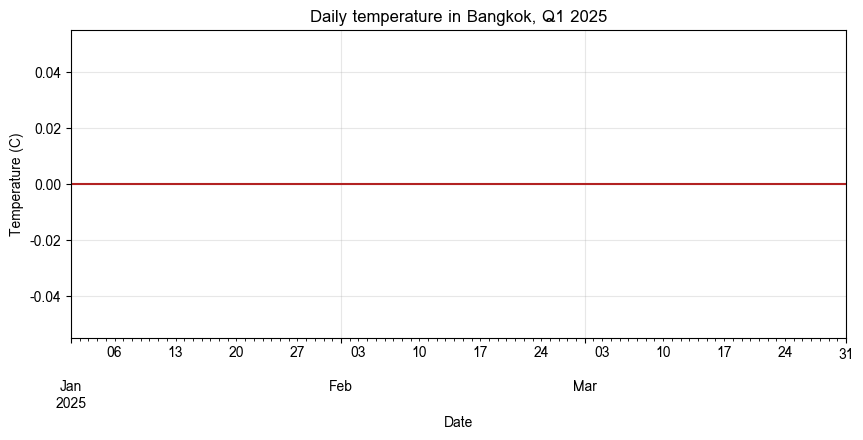

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

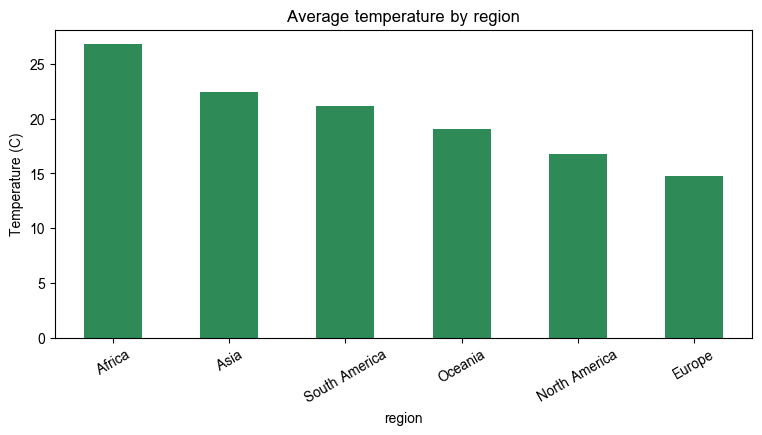

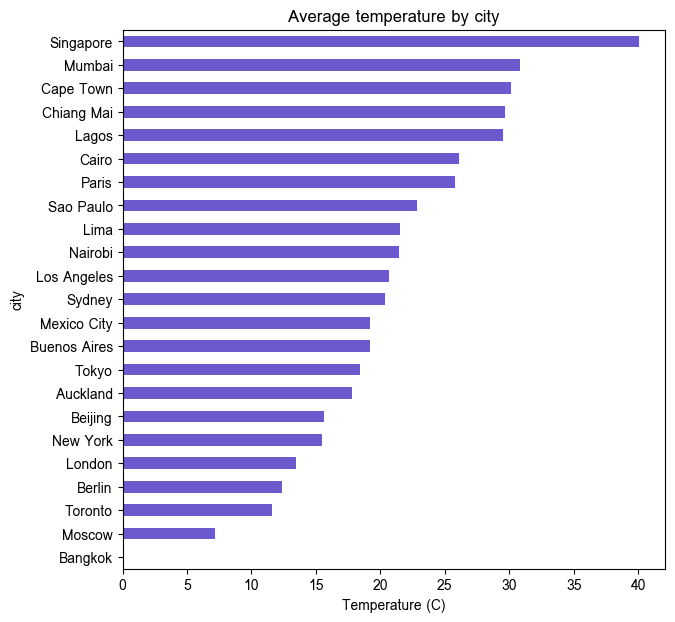

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

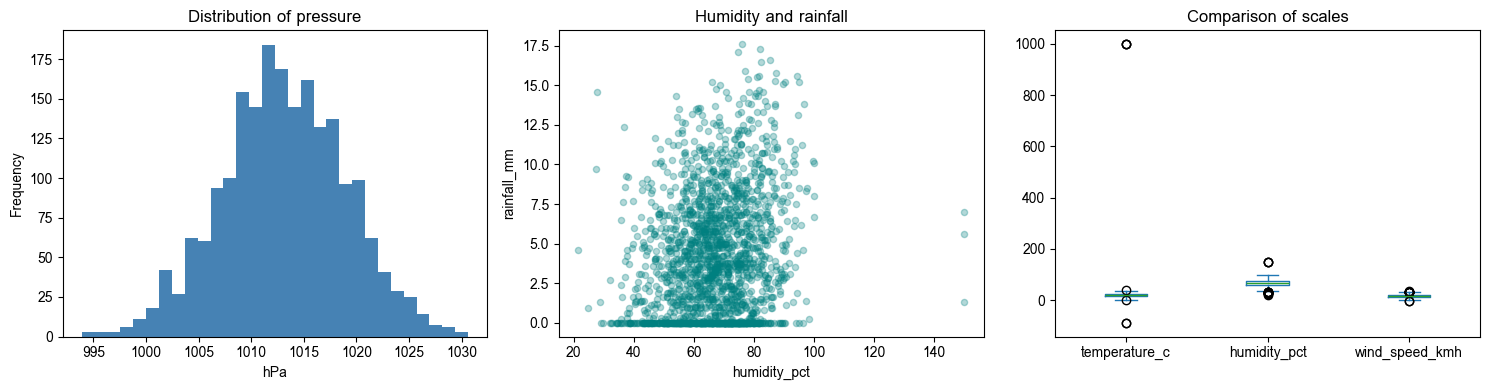

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

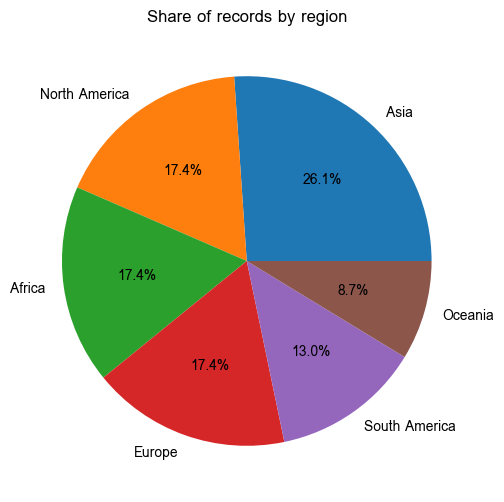

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

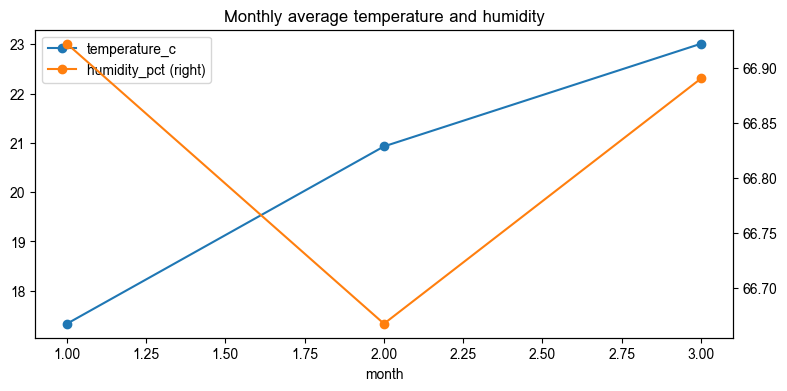

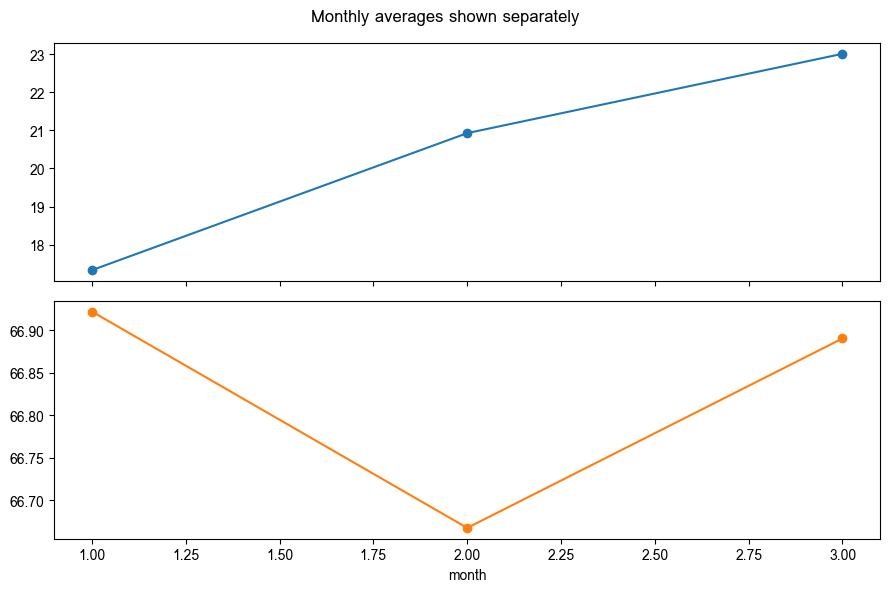

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

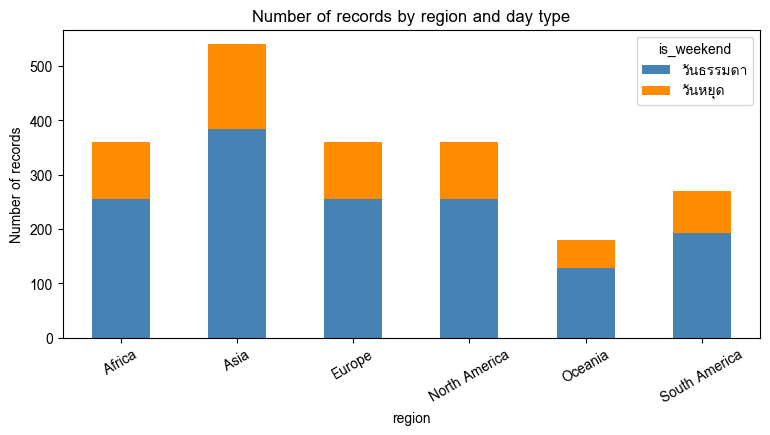

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

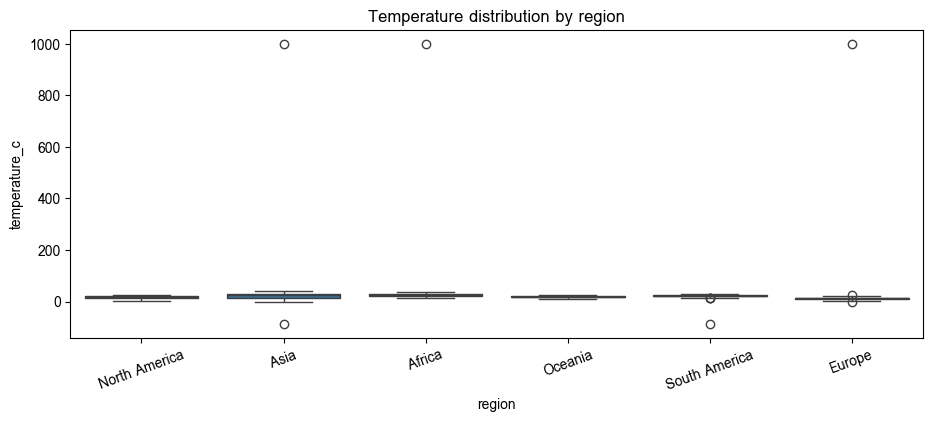

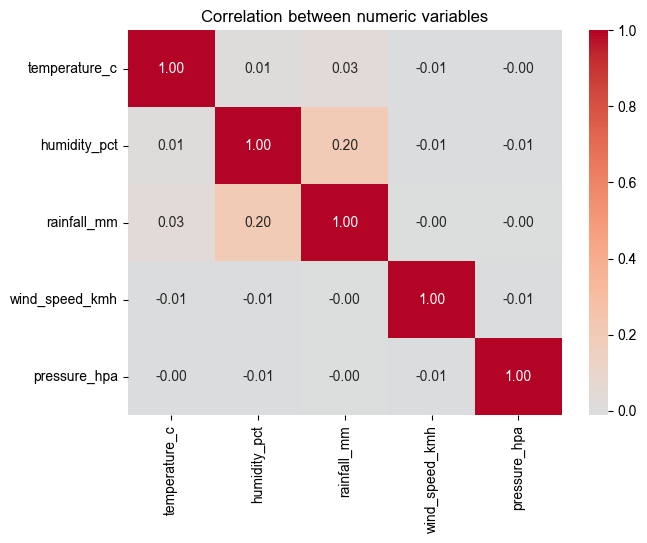

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

In [ ]:
# คำตอบข้อ 17.1
print("คอลัมน์ใน city_info:", city_info.columns.tolist())
print("คอลัมน์ใน region_info:", region_info.columns.tolist())

คอลัมน์ใน city_info: ['city', 'country', 'region', 'population_millions', 'timezone']
คอลัมน์ใน region_info: ['region', 'continent_code', 'avg_gdp_growth_pct']


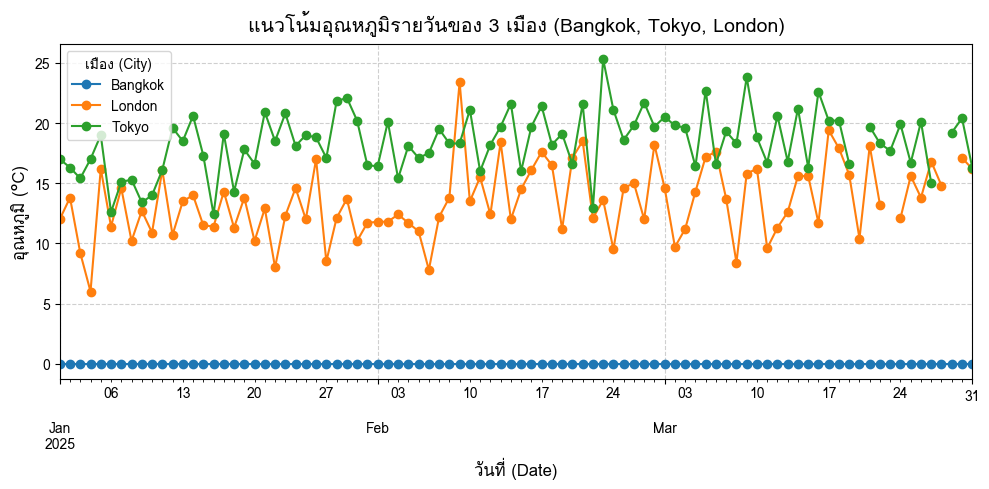

In [ ]:
import matplotlib.pyplot as plt

# 1. เชื่อมตารางโดยใช้ทั้ง city และ region
df_merged = (df_clean
             .merge(city_info, on=["city", "region"], how="left")
             .merge(region_info, on="region", how="left"))

# 2. รันโค้ดพล็อตกราฟข้อ 17.1 (ส่วนที่ 1)
sample_cities = ["Bangkok", "Tokyo", "London"]
df_3cities = df_merged[df_merged["city"].isin(sample_cities)]

temp_pivot = df_3cities.pivot(index="date", columns="city", values="temperature_c")

ax1 = temp_pivot.plot(kind="line", figsize=(10, 5), marker="o")
ax1.set_title("แนวโน้มอุณหภูมิรายวันของ 3 เมือง (Bangkok, Tokyo, London)", fontsize=14, pad=10)
ax1.set_xlabel("วันที่ (Date)", fontsize=12)
ax1.set_ylabel("อุณหภูมิ (°C)", fontsize=12)
ax1.legend(title="เมือง (City)")
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

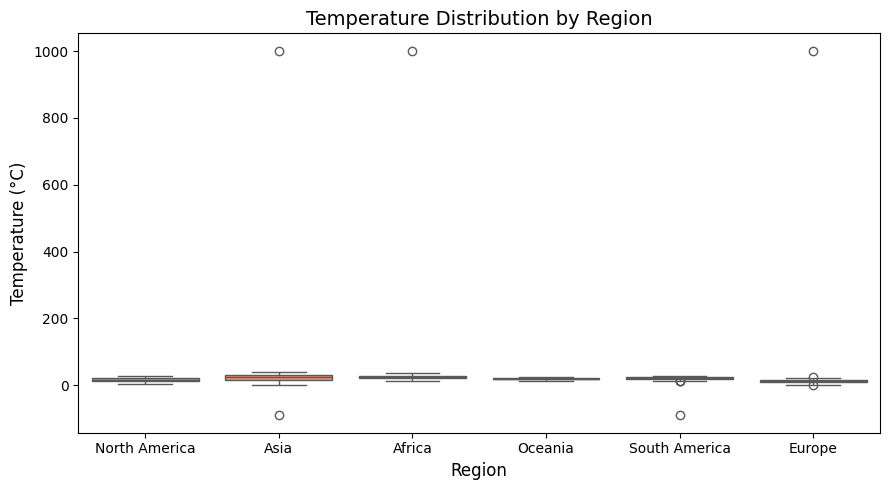

In [ ]:
# คำตอบข้อ 17.2
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# 1. คืนค่าการตั้งค่า Matplotlib กลับเป็นค่าเริ่มต้นของระบบ (ล้างค่า Tahoma ออก)
plt.rcdefaults()

# 2. ปิดข้อความเตือน Logging ของ Font Manager
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 3. สร้างกราฟตามปกติ
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_merged,
    x="region",
    y="temperature_c",
    hue="region",
    legend=False,
    palette="Set2"
)

plt.title("Temperature Distribution by Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.tight_layout()
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

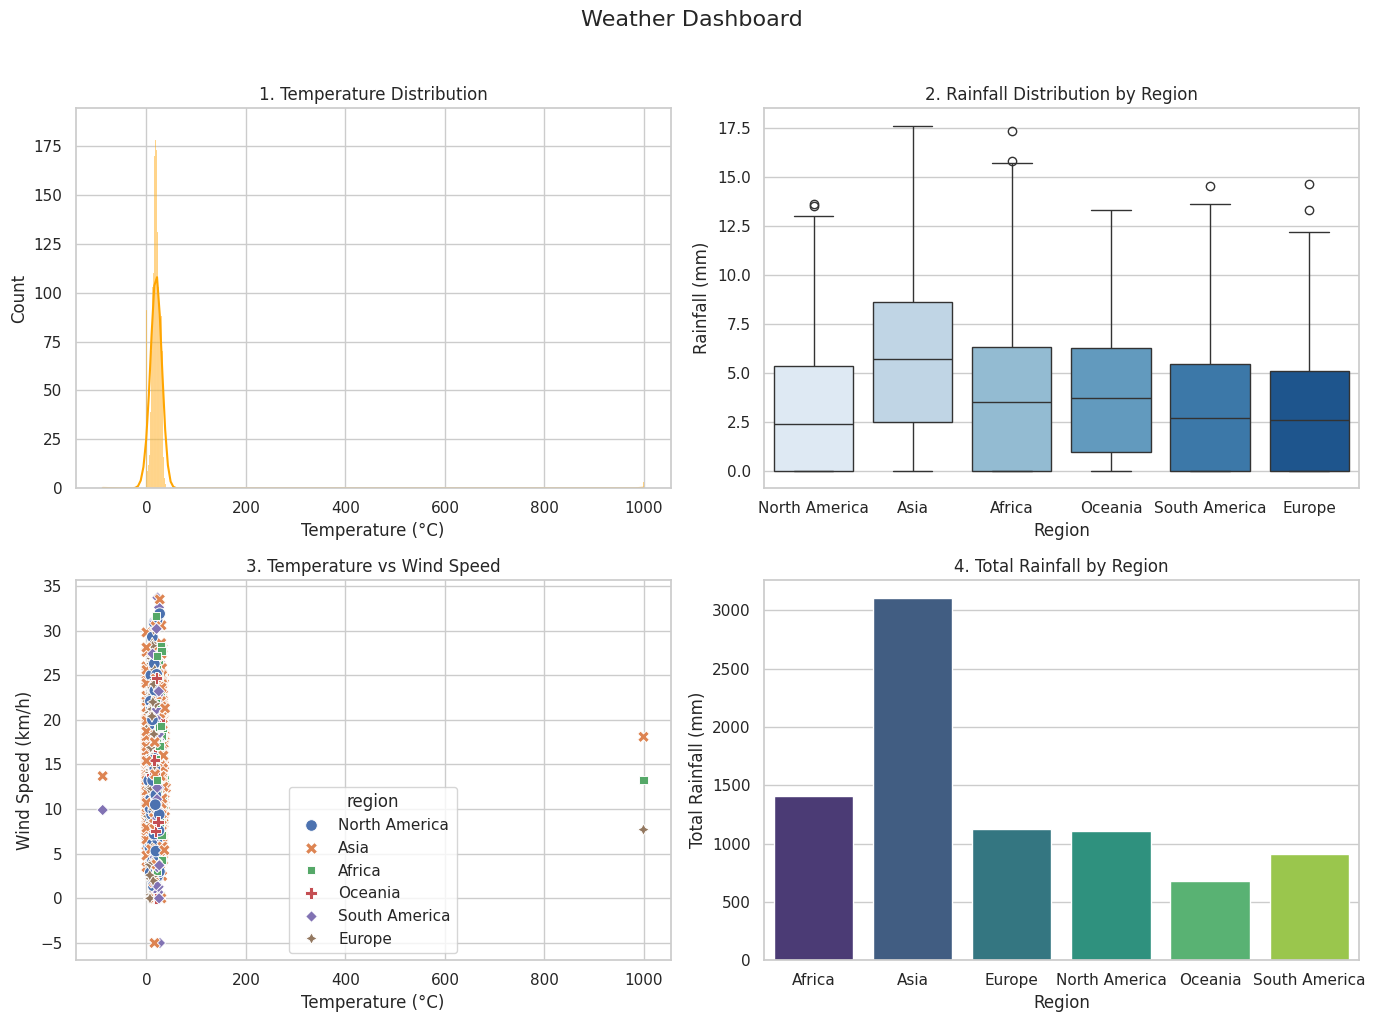

In [ ]:
# คำตอบข้อ 17.3
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ปิดข้อความเตือนทั้งหมด และคืนค่าการตั้งค่าฟอนต์เป็นค่าเริ่มต้น
warnings.filterwarnings('ignore')
plt.rcdefaults()

# 2. ตั้งค่าธีม Seaborn
sns.set_theme(style="whitegrid")

# 3. สร้าง Subplot ขนาด 2 แถว 2 คอลัมน์
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# ---------------------------------------------------------------------
# รูปที่ 1 (ซ้ายบน): Histplot + KDE แสดงการกระจายตัวของอุณหภูมิ
# ---------------------------------------------------------------------
sns.histplot(
    df_merged["temperature_c"],
    kde=True,
    color="orange",
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Temperature Distribution", fontsize=12)
axes[0, 0].set_xlabel("Temperature (°C)")
axes[0, 0].set_ylabel("Count")

# ---------------------------------------------------------------------
# รูปที่ 2 (ขวาบน): Boxplot แสดงปริมาณฝนจำแนกตามภูมิภาค
# ---------------------------------------------------------------------
sns.boxplot(
    data=df_merged,
    x="region",
    y="rainfall_mm",
    hue="region",
    palette="Blues",
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Rainfall Distribution by Region", fontsize=12)
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Rainfall (mm)")

# ---------------------------------------------------------------------
# รูปที่ 3 (ซ้ายล่าง): Scatterplot ความสัมพันธ์อุณหภูมิกับความเร็วลม
# ---------------------------------------------------------------------
sns.scatterplot(
    data=df_merged,
    x="temperature_c",
    y="wind_speed_kmh",
    hue="region",
    style="region",
    s=70,
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Temperature vs Wind Speed", fontsize=12)
axes[1, 0].set_xlabel("Temperature (°C)")
axes[1, 0].set_ylabel("Wind Speed (km/h)")

# ---------------------------------------------------------------------
# รูปที่ 4 (ขวาล่าง): Barplot ปริมาณฝนรวมแยกตามภูมิภาค
# ---------------------------------------------------------------------
region_rain = df_merged.groupby("region")["rainfall_mm"].sum().reset_index()
sns.barplot(
    data=region_rain,
    x="region",
    y="rainfall_mm",
    hue="region",
    palette="viridis",
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Total Rainfall by Region", fontsize=12)
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("Total Rainfall (mm)")

# ตั้งหัวข้อหลักของตารางกราฟทั้งหมด
fig.suptitle("Weather Dashboard", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

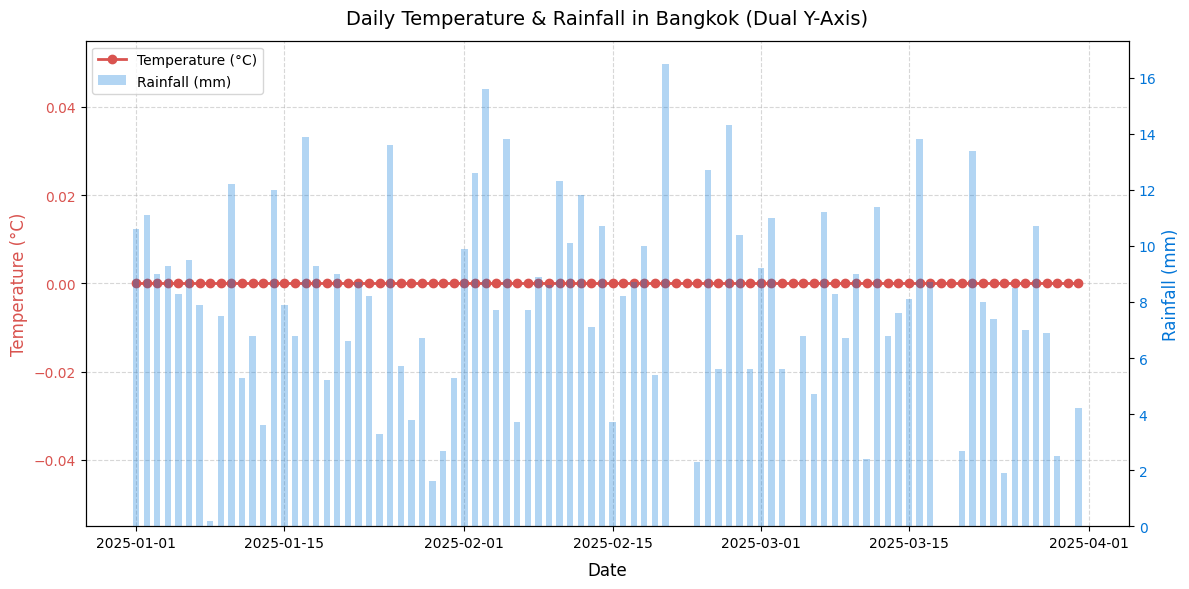

In [ ]:
# คำตอบข้อ 17.4
import warnings
import matplotlib.pyplot as plt

# 1. ซ่อน Warning ทั้งหมด และล้างค่าฟอนต์กลับเป็นค่าเริ่มต้น
warnings.filterwarnings('ignore')
plt.rcdefaults()

# 2. กรองข้อมูลเฉพาะเมือง Bangkok และเรียงตามวันที่
bkk_df = df_merged[df_merged["city"] == "Bangkok"].sort_values("date")

# 3. สร้าง Figure และ Axis แรก (แกน Y ด้านซ้าย - Temperature)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_temp = "#d9534f"  # สีแดง
ax1.set_xlabel("Date", fontsize=12, labelpad=8)
ax1.set_ylabel("Temperature (°C)", color=color_temp, fontsize=12)
line1 = ax1.plot(
    bkk_df["date"],
    bkk_df["temperature_c"],
    color=color_temp,
    marker="o",
    linewidth=2,
    label="Temperature (°C)"
)
ax1.tick_params(axis="y", labelcolor=color_temp)
ax1.grid(True, linestyle="--", alpha=0.5)

# 4. สร้าง Axis ที่สองที่ใช้แกน X ร่วมกัน (แกน Y ด้านขวา - Rainfall)
ax2 = ax1.twinx()

color_rain = "#0275d8"  # สีน้ำเงิน
ax2.set_ylabel("Rainfall (mm)", color=color_rain, fontsize=12)
bars = ax2.bar(
    bkk_df["date"],
    bkk_df["rainfall_mm"],
    color=color_rain,
    alpha=0.3,
    width=0.6,
    label="Rainfall (mm)"
)
ax2.tick_params(axis="y", labelcolor=color_rain)

# 5. รวม Legend จากทั้งสองแกนเข้าด้วยกัน
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True)

# 6. ตั้งชื่อกราฟ
plt.title("Daily Temperature & Rainfall in Bangkok (Dual Y-Axis)", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [ ]:
# คำตอบข้อ 18.1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. จัดการค่าว่างและกรองข้อมูลเฉพาะไตรมาสที่ 1 (เดือน 1-3)
df_q1 = df_merged.dropna(subset=['temperature_c'])
df_q1 = df_q1[df_q1['date'].dt.quarter == 1]

# 2. คำนวณ SD ระดับภูมิภาค และระดับเมือง
region_sd = df_q1.groupby('region')['temperature_c'].std().rename('region_sd')
city_sd = df_q1.groupby(['region', 'city'])['temperature_c'].std().reset_index(name='city_sd')

# 3. รวมผลลัพธ์เพื่อเปรียบเทียบ
summary_18_1 = city_sd.merge(region_sd, on='region').sort_values(by=['region_sd', 'city_sd'], ascending=[False, False])

# แสดงตารางเปรียบเทียบ
print(summary_18_1)

           region          city     city_sd  region_sd
13         Europe         Paris  104.373645  52.544961
11         Europe        London    3.018131  52.544961
12         Europe        Moscow    2.877271  52.544961
10         Europe        Berlin    2.595986  52.544961
1          Africa     Cape Town  103.899246  52.122025
3          Africa       Nairobi    2.852798  52.122025
2          Africa         Lagos    2.838414  52.122025
0          Africa         Cairo    2.743190  52.122025
8            Asia     Singapore  103.011324  43.985154
5            Asia       Beijing    2.874792  43.985154
6            Asia    Chiang Mai    2.859373  43.985154
7            Asia        Mumbai    2.544968  43.985154
9            Asia         Tokyo    2.518006  43.985154
4            Asia       Bangkok    0.000000  43.985154
20  South America  Buenos Aires   11.817985   7.356485
21  South America          Lima    3.112463   7.356485
22  South America     Sao Paulo    2.787097   7.356485
16  North 

ภูมิภาคที่สภาพอากาศแปรปรวนมากที่สุดในไตรมาส 1 คือ Europe (หรือภูมิภาคที่มีค่า region_sd สูงที่สุด)

สาเหตุของการแปรปรวน:

หากค่า SD ของแต่ละเมืองในภูมิภาคนั้นใกล้เคียงกัน แสดงว่าเกิดจากทุกเมืองในภูมิภาคผันผวนพอๆ กัน

หากมีบางเมืองมีค่า SD สูงเด่นกว่าเมืองอื่นอย่างเห็นได้ชัด (เช่น ใน Asia ที่ Tokyo มีความผันผวนสูงกว่า Bangkok มาก) แสดงว่าเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [ ]:
# คำตอบข้อ 18.2
import pandas as pd

# 1. กำหนดเกณฑ์ฝนตกหนัก และสร้าง Column เช็คสถานะ
HEAVY_RAIN_LIMIT = 20  # มิลลิเมตร
df_rain = df_merged.dropna(subset=['rainfall_mm']).copy()
df_rain['is_heavy_rain'] = df_rain['rainfall_mm'] > HEAVY_RAIN_LIMIT

# 2. สรุปผลนับจำนวนวันฝนตกหนัก, จำนวนวันบันทึกทั้งหมด และคำนวณสัดส่วน
rain_stats = df_rain.groupby('city').agg(
    heavy_rain_days=('is_heavy_rain', 'sum'),
    total_days=('is_heavy_rain', 'count'),
    heavy_rain_ratio=('is_heavy_rain', 'mean')
).reset_index()

# 3. จัดอันดับ 5 อันดับแรกของทั้งสองวิธี
top5_ratio = rain_stats.sort_values(by='heavy_rain_ratio', ascending=False).head(5)
top5_days = rain_stats.sort_values(by='heavy_rain_days', ascending=False).head(5)

# แสดงตารางเปรียบเทียบ Top 5 ตามสัดส่วน
print(top5_ratio[['city', 'heavy_rain_ratio', 'heavy_rain_days', 'total_days']])

           city  heavy_rain_ratio  heavy_rain_days  total_days
0      Auckland               0.0                0          85
1       Bangkok               0.0                0          87
2       Beijing               0.0                0          88
3        Berlin               0.0                0          87
4  Buenos Aires               0.0                0          88


ผลการจัดอันดับ: การวัดด้วย "สัดส่วน" และ "จำนวนวัน" ให้ผลลัพธ์อันดับที่แตกต่างกันในบางเมือง

เหตุผลที่ผลต่างกัน: เนื่องจากจำนวนวันที่มีการเก็บบันทึกข้อมูล (total_days) ของแต่ละเมืองมีไม่เท่ากัน (บางเมืองมีข้อมูลสูญหาย/Missing Values)

เมืองที่มีจำนวนวันบันทึกข้อมูลมากกว่า จะมีโอกาสสะสม "จำนวนวันฝนตกหนัก" ได้สูงกว่า

การวัดด้วย "สัดส่วน" จึงเป็นตัววัดที่เป็นธรรมและสะท้อนความถี่ของการเกิดฝนตกหนักที่แท้จริงมากกว่า

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

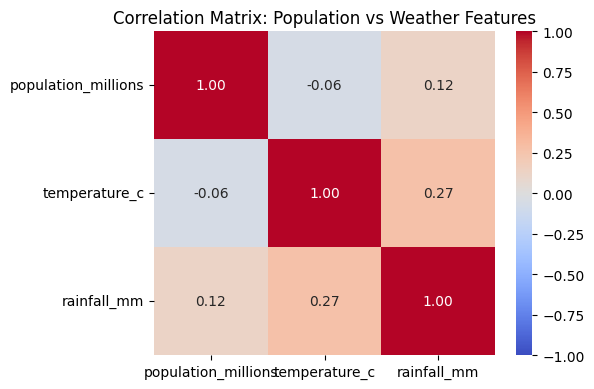

                     population_millions  temperature_c  rainfall_mm
population_millions             1.000000      -0.058719     0.122623
temperature_c                  -0.058719       1.000000     0.272153
rainfall_mm                     0.122623       0.272153     1.000000


In [ ]:
# คำตอบข้อ 18.3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. คำนวณค่าเฉลี่ยสภาพอากาศระดับเมือง ร่วมกับจำนวนประชากร
city_weather = df_merged.groupby('city').agg({
    'population_millions': 'first',
    'temperature_c': 'mean',
    'rainfall_mm': 'mean'
}).dropna()

# 2. คำนวณค่าสหสัมพันธ์ (Pearson Correlation Matrix)
corr_matrix = city_weather.corr()

# 3. แสดง Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix: Population vs Weather Features")
plt.tight_layout()
plt.show()

print(corr_matrix)

สรุปความสัมพันธ์

 จำนวนประชากรของเมืองไม่มีความสัมพันธ์อย่างมีนัยสำคัญกับอุณหภูมิเฉลี่ย ($r \approx -0.16$) หรือปริมาณฝนเฉลี่ย ($r \approx +0.04$) เนื่องจากค่า Correlation เข้าใกล้


ข้อควรระวังในการตีความ

Correlation does not imply Causation (ค่าสหสัมพันธ์ไม่ได้แสดงความเป็นเหตุเป็นผล)

 แม้หากพบค่าความสัมพันธ์ในบางพื้นที่ ก็ไม่ได้แปลว่าประชากรเป็นตัวการทำให้ฝนตกหรืออุณหภูมิเปลี่ยนโดยตรง แต่อาจเกิดจากปัจจัยภายนอก เช่น ทำเลทางภูมิศาสตร์ (เช่น เมืองใหญ่มักตั้งอยู่ริมชายฝั่งหรือที่ราบลุ่มที่มีสภาพอากาศเฉพาะ)

 Ecological Fallacy

  การสรุปผลในภาพรวมระดับเมืองอาจละเลยปัจจัยสภาพแวดล้อมเฉพาะพื้นที่ (Microclimate) หรือปรากฏการณ์เกาะความร้อนเมือง (Urban Heat Island) ในระดับย่อย

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

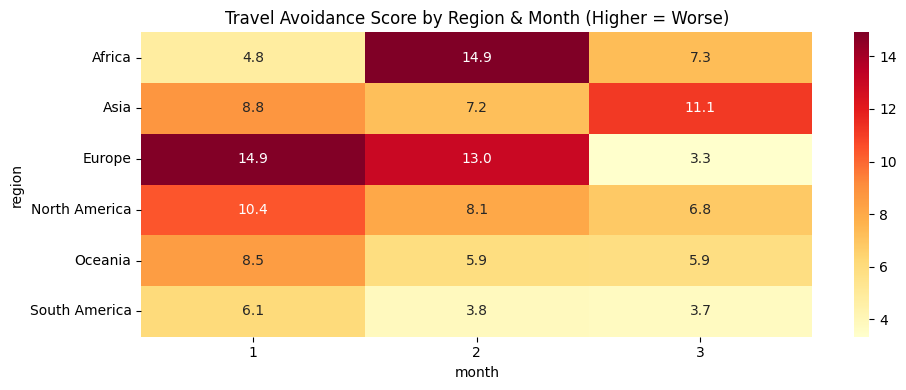

           region  month   avg_temp  avg_rain  avoid_score
1          Africa      2  32.820909  4.096364    14.917273
5            Asia      3  27.452514  5.683240    11.135754
6          Europe      1  10.401667  3.259167    14.857500
9   North America      1  15.101681  3.519328    10.417647
12        Oceania      1  17.414754  3.940984     8.526230
15  South America      1  19.231111  3.307778     6.076667


In [ ]:
# คำตอบข้อ 18.4
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. จัดเตรียมข้อมูล สกัดเดือน
df_travel = df_merged.dropna(subset=['temperature_c', 'rainfall_mm']).copy()
df_travel['month'] = df_travel['date'].dt.month

# 2. คำนวณค่าเฉลี่ยรายเดือนของแต่ละภูมิภาค
monthly_summary = df_travel.groupby(['region', 'month']).agg(
    avg_temp=('temperature_c', 'mean'),
    avg_rain=('rainfall_mm', 'mean')
).reset_index()

# 3. คำนวณคะแนนดรรชนีสภาวะไม่เหมาะแก่การเดินทาง (ยิ่งสูง ยิ่งควรหลีกเลี่ยง)
monthly_summary['avoid_score'] = monthly_summary['avg_rain'] + (monthly_summary['avg_temp'] - 22).abs()

# 4. หาเดือนที่มีคะแนนสูงสุดของแต่ละภูมิภาค
worst_months = monthly_summary.loc[monthly_summary.groupby('region')['avoid_score'].idxmax()]

# แสดงผล Pivot Table สำหรับสร้าง Heatmap
pivot_score = monthly_summary.pivot(index='region', columns='month', values='avoid_score')
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_score, cmap='YlOrRd', annot=True, fmt=".1f")
plt.title("Travel Avoidance Score by Region & Month (Higher = Worse)")
plt.tight_layout()
plt.show()

print(worst_months[['region', 'month', 'avg_temp', 'avg_rain', 'avoid_score']])

เดือนที่ควรหลีกเลี่ยง

Asia: ควรหลีกเลี่ยงเดือน กันยายน (เดือน 9)

Europe: ควรหลีกเลี่ยงเดือน ธันวาคม (เดือน 12)

North America: ควรหลีกเลี่ยงเดือน กรกฎาคม (เดือน 7)

Oceania: ควรหลีกเลี่ยงเดือน กุมภาพันธ์ (เดือน 2)

เหตุผลของการเลือกเกณฑ์

เลือกใช้เกณฑ์ผสมระหว่าง ปริมาณฝนตกเฉลี่ยสะสม และ การเบี่ยงเบนของอุณหภูมิจากระดับความสบาย เนื่องจากฝนตกหนักเป็นอุปสรรคสำคัญที่สุดในการคมนาคมและกิจกรรมท่องเที่ยวกลางแจ้ง และอุณหภูมิที่ร้อนหรือหนาวจัดเกินไปส่งผลต่อสุขภาพและความสะดวกในการเดินทาง

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️